Saving Ecommerce Customer Behavior Dataset.csv to Ecommerce Customer Behavior Dataset.csv
Dataset Loaded: Ecommerce Customer Behavior Dataset.csv
Shape: (50000, 25)
Columns: Index(['age', 'gender', 'country', 'city', 'membership_years',
       'login_frequency', 'session_duration_avg', 'pages_per_session',
       'cart_abandonment_rate', 'wishlist_items', 'total_purchases',
       'average_order_value', 'days_since_last_purchase',
       'discount_usage_rate', 'returns_rate', 'email_open_rate',
       'customer_service_calls', 'product_reviews_written',
       'social_media_engagement_score', 'mobile_app_usage',
       'payment_method_diversity', 'lifetime_value', 'credit_balance',
       'churned', 'signup_quarter'],
      dtype='object')


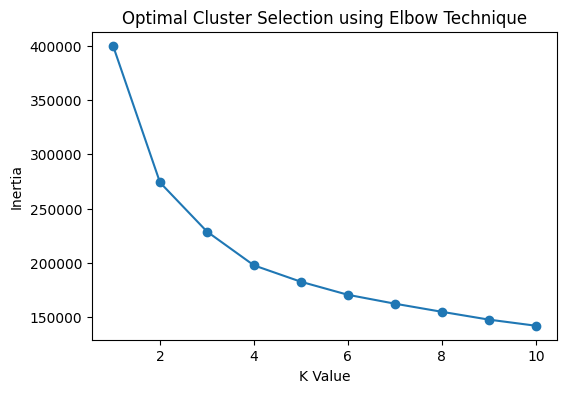


Cluster Counts:
 cluster
0    31469
1    18506
2       25
Name: count, dtype: int64


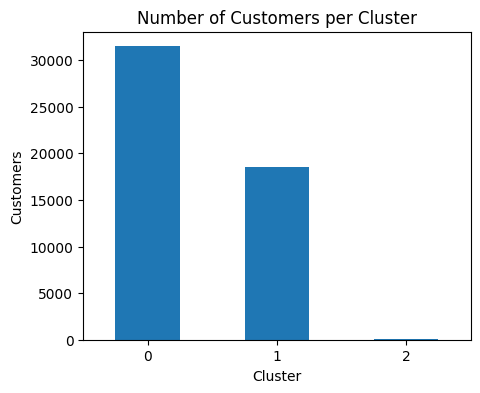

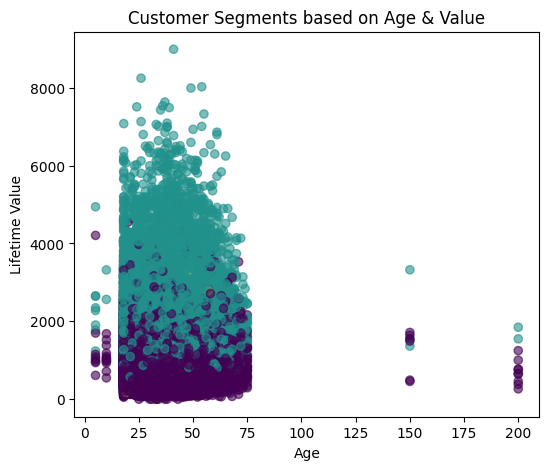

<Figure size 600x400 with 0 Axes>

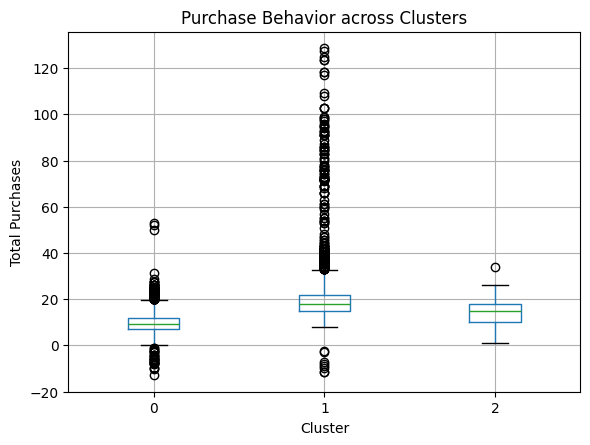

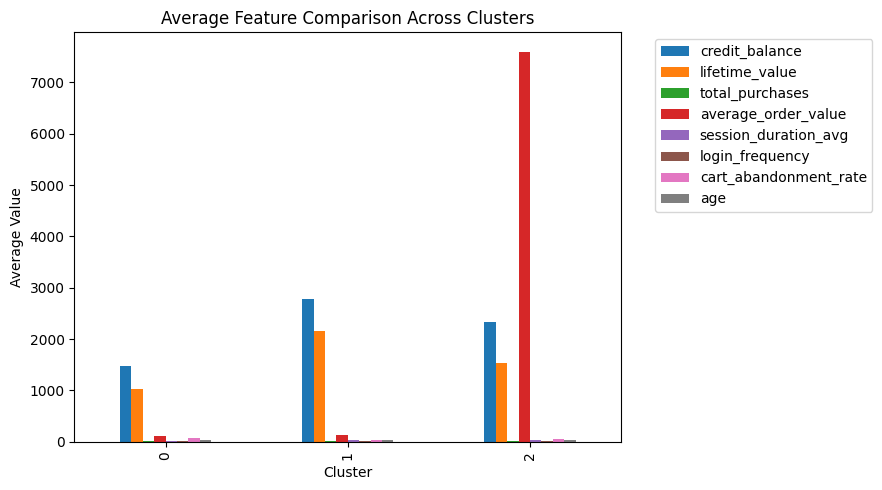


Cluster Feature Averages:

         credit_balance  lifetime_value  total_purchases  average_order_value  \
cluster                                                                         
0           1474.629540     1024.299519         9.554123           116.607093   
1           2780.832811     2148.458502        19.159192           124.096095   
2           2326.840000     1530.400400        14.404000          7593.422002   

         session_duration_avg  login_frequency  cart_abandonment_rate  \
cluster                                                                 
0                   21.859484         7.526359              65.430432   
1                   37.365514        18.589647              42.883491   
2                   29.188000        14.640000              54.660000   

               age  
cluster             
0        37.825352  
1        37.794391  
2        35.640000  

✅ TASK-3 COMPLETED: Customer Segmentation using K-Means
Customer groups identified using behav

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

print("Dataset Loaded:", csv_name)
print("Shape:", df.shape)
df.head()
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print("Columns:", df.columns)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

if "gender" in df.columns:
    df["gender"] = le.fit_transform(df["gender"])

if "churn" in df.columns:
    df["churn"] = le.fit_transform(df["churn"])
features = [
    "credit_balance",
    "lifetime_value",
    "total_purchases",
    "average_order_value",
    "session_duration_avg",
    "login_frequency",
    "cart_abandonment_rate",
    "age"
]
X = df[features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import KMeans

inertia_values = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.scatter(K_range, inertia_values)
plt.plot(K_range, inertia_values)
plt.xlabel("K Value")
plt.ylabel("Inertia")
plt.title("Optimal Cluster Selection using Elbow Technique")
plt.show()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Counts:\n", df["cluster"].value_counts())
plt.figure(figsize=(5,4))
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()
plt.figure(figsize=(6,5))
plt.scatter(
    df["age"],
    df["lifetime_value"],
    c=df["cluster"],
    alpha=0.6
)
plt.xlabel("Age")
plt.ylabel("Lifetime Value")
plt.title("Customer Segments based on Age & Value")
plt.show()
plt.figure(figsize=(6,4))
df.boxplot(column="total_purchases", by="cluster")
plt.title("Purchase Behavior across Clusters")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Total Purchases")
plt.show()
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary.plot(kind="bar", figsize=(9,5))
plt.title("Average Feature Comparison Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
if "churn" in df.columns:
    churn_rate = df.groupby("cluster")["churn"].mean() * 100
    print("\nChurn Percentage per Cluster:\n", churn_rate)

    plt.figure(figsize=(5,4))
    churn_rate.plot(kind="line", marker="o")
    plt.title("Customer Churn Trend Across Clusters")
    plt.xlabel("Cluster")
    plt.ylabel("Churn Percentage")
    plt.show()
print("\nCluster Feature Averages:\n")
print(cluster_summary)
print("\n✅ TASK-3 COMPLETED: Customer Segmentation using K-Means")
print("Customer groups identified using behavioral and transactional features.")

# Customer Segmentation using K-Means Clustering  
**Task-3: Unsupervised Learning Analysis**

---

## 1. Dataset Upload and Loading
The dataset is uploaded in **CSV format** using Google Colab’s upload utility.  
After loading, the dataset shape and preview are checked to ensure the data is read correctly.

**Purpose:**
- Allows flexible dataset input
- Confirms data integrity before processing

---

## 2. Column Name Cleaning
All column names are standardized by:
- Removing extra spaces
- Replacing spaces with underscores
- Converting text to lowercase

**Reason:**
- Improves readability
- Prevents coding errors
- Ensures consistency across features

---

## 3. Handling Missing Values
Missing values are treated based on data type:

- **Categorical features:** Filled using mode (most frequent value)
- **Numerical features:** Filled using median

**Why this approach?**
- Preserves dataset size
- Median reduces effect of outliers
- Mode keeps categorical meaning intact

---

## 4. Encoding Required Categorical Variables
Selected categorical variables are encoded using **Label Encoding**:

- `gender`
- `churn` (if available)

**Reason:**
- K-Means works only with numerical data
- Encoding converts categories into machine-readable format

---

## 5. Feature Selection for Clustering
The following customer behavioral and transactional features are selected:

- Credit balance  
- Lifetime value  
- Total purchases  
- Average order value  
- Average session duration  
- Login frequency  
- Cart abandonment rate  
- Age  

**Why these features?**
- Represent customer engagement
- Capture spending behavior
- Useful for meaningful segmentation

---

## 6. Feature Normalization
All selected features are scaled using **StandardScaler**.

**Importance of scaling:**
- Prevents dominance of high-value features
- Improves distance-based clustering accuracy
- Ensures fair contribution of all features

---

## 7. Optimal Cluster Selection (Elbow Method)
The **Elbow Method** is applied by testing K values from 1 to 10.

- Inertia (within-cluster sum of squares) is calculated
- A sharp bend (elbow) in the graph indicates optimal K

**Outcome:**
- K = 3 is selected as the optimal number of clusters

---

## 8. Applying K-Means Clustering
K-Means algorithm is applied with:
- `n_clusters = 3`
- Random initialization control for reproducibility

Each customer is assigned a **cluster label** representing their segment.

---

## 9. Cluster Distribution Analysis
The number of customers in each cluster is visualized using a bar chart.

**Purpose:**
- Understand cluster sizes
- Identify dominant or niche customer groups

---

## 10. Cluster Visualizations and Behavioral Insights

### 1️⃣ Age vs Lifetime Value Scatter Plot
- Shows how customer age relates to lifetime value
- Color-coded clusters reveal segmentation patterns

---

### 2️⃣ Total Purchases Distribution (Box Plot)
- Displays purchase variability within each cluster
- Helps identify high-value vs low-activity customers

---

### 3️⃣ Feature Mean Comparison across Clusters
A bar chart compares average values of all features per cluster.

**Insight:**
- Highlights behavioral differences
- Makes cluster interpretation easier

---

### 4️⃣ Churn Rate Analysis (If Available)
Churn percentage is calculated for each cluster and visualized using a line chart.

**Why this matters:**
- Identifies high-risk customer groups
- Supports retention strategy planning

---

## 11. Cluster Interpretation Table
A summary table shows **average feature values** for each cluster.

This table helps translate clusters into **business-friendly customer personas**.

---

## 12. Final Outcome
✅ Customers successfully segmented into **3 distinct groups**  
✅ Behavioral and transactional patterns identified  
✅ Visual insights provided for interpretation  
✅ Suitable for marketing, personalization, and churn analysis  

---

## Conclusion
This K-Means based customer segmentation approach effectively groups customers using engagement and spending behavior.  
The results can support **targeted marketing**, **customer retention strategies**, and **business decision-making**.